In [1]:
!pip install vedo

Defaulting to user installation because normal site-packages is not writeable



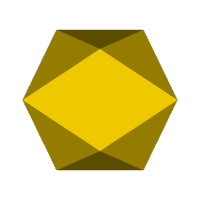

In [23]:
from vedo import Mesh, show

# Load the mesh and optionally a texture
mesh = Mesh("ico.obj")
# mesh.texture("path/to/your/texture.jpg") # Optional: load texture

# Display the object in an interactive windowmesh)
mesh

/tmp/ipykernel_16763/4124249326.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


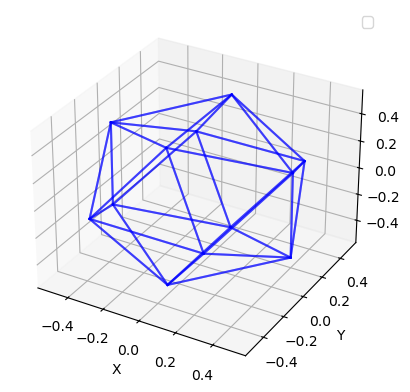

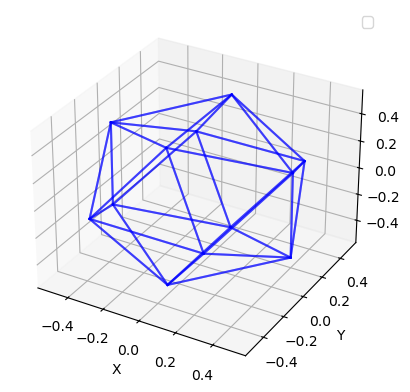

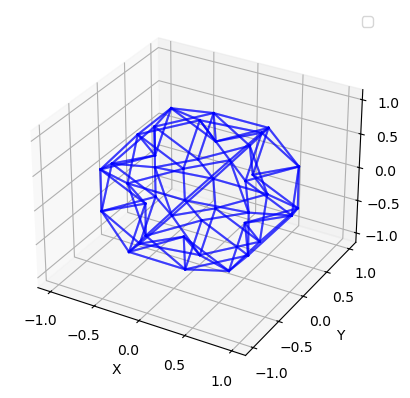

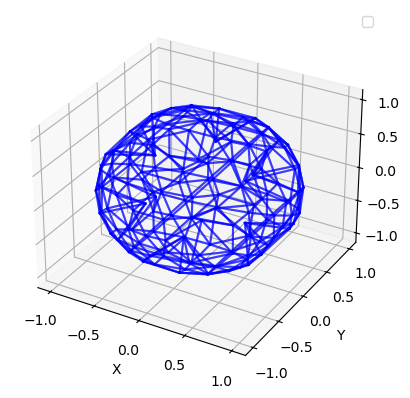

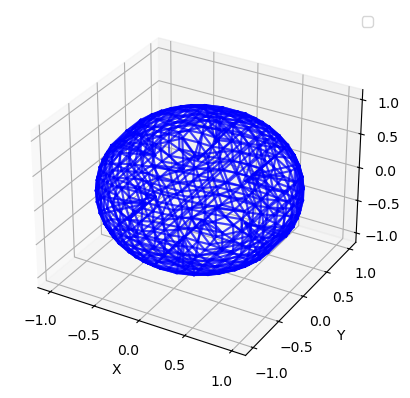

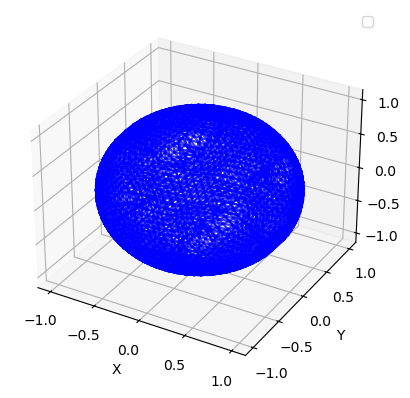


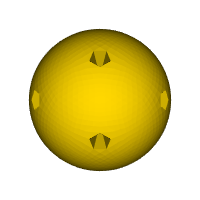

In [3]:
import matplotlib.pyplot as plt
import numpy as np

class vertex:
    def __init__(self, c:list, idx:int = None):
        self.coord = c
        self.degree = 0
        self.index = idx

class edge:
    def __init__(self, v_:tuple):
        self.bounds = v_

    def half(self):
        ini = self.bounds[0]
        end = self.bounds[1]
        mid = vertex((ini.coord + end.coord)/2)
        return([edge((ini, mid)), edge((mid, end))])
    
    def mid_vertex(self):
        if type(self.bounds[1]) == vertex:
            return vertex((self.bounds[0].coord + self.bounds[1].coord)/2)
        else:
            print(type(self.bounds[0]))

class obj:
    def __init__(self, V = None, F = None):
        self.vlist = V
        self.faces = F
        self.edges = self._construct()

    def _construct(self):
        E = []
        for face in self.faces:
            a, b, c = face
            E.append(edge((self.vlist[a-1], self.vlist[b-1])))
            E.append(edge((self.vlist[b-1], self.vlist[c-1])))
            E.append(edge((self.vlist[c-1], self.vlist[a-1])))
        
        return E

    def print_obj(self, save = None, path = None):
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')


        x_vals = [v.coord[0] for v in self.vlist]
        y_vals = [v.coord[1] for v in self.vlist]
        z_vals = [v.coord[2] for v in self.vlist]


        ax.scatter(x_vals, y_vals, z_vals, c='r', marker="")


        if self.faces:
            for face in self.faces:
      
                v1 = self.vlist[face[0] - 1].coord
                v2 = self.vlist[face[1] - 1].coord
                v3 = self.vlist[face[2] - 1].coord
                

                ax.plot([v1[0], v2[0]], [v1[1], v2[1]], [v1[2], v2[2]], 'b-', alpha=0.5)
  
                ax.plot([v2[0], v3[0]], [v2[1], v3[1]], [v2[2], v3[2]], 'b-', alpha=0.5)
  
                ax.plot([v3[0], v1[0]], [v3[1], v1[1]], [v3[2], v1[2]], 'b-', alpha=0.5)

        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        plt.legend()

        if save:
            plt.savefig(path)
        else:
            plt.show()

        
    


def read_obj(path):
    
    V = []
    F = []
    count = 0 
    with open(path, "r") as f:
        for line in f.readlines():
            if line[0] == "v":
                count += 1
                a, b, c = line.split()[1:]
                V.append(vertex(np.array([float(a), float(b), float(c)]), count))
            elif line[0] == "f":
                l = line.split()[1:]
                a, b, c = l
                F.append((int(a),int(b),int(c)))
            else:
                print("ERROR")

    return obj(V,F)




icosaedro = read_obj("ico.obj")

icosaedro.print_obj()

def improve_obj(obje: obj):
    old_v = obje.vlist
    facs = obje.faces
    new_vs = []
    new_faces = []

  
    def get_sphere_midpoint(p1, p2):
        mid = (p1 + p2) / 2
        return mid / np.linalg.norm(mid)

    for f in facs:
        c1 = old_v[f[0] - 1].coord
        c2 = old_v[f[1] - 1].coord
        c3 = old_v[f[2] - 1].coord
        idx_base = len(old_v) + len(new_vs)
        

        v1 = vertex(get_sphere_midpoint(c1, c2), idx_base + 1)
        new_vs.append(v1)
        
        v2 = vertex(get_sphere_midpoint(c1, c3), idx_base + 2)
        new_vs.append(v2)
        
        v3 = vertex(get_sphere_midpoint(c2, c3), idx_base + 3)
        new_vs.append(v3) 

   
        f1 = (old_v[f[0] - 1].index, v1.index, v2.index)
        
 
        f2 = (v1.index, old_v[f[1] - 1].index, v3.index)
        

        f3 = (v2.index, v3.index, old_v[f[2] - 1].index)
        
   
        f4 = (v1.index, v3.index, v2.index)
        
        new_faces += [f1, f2, f3, f4]

    old_v += new_vs
    return obj(old_v, new_faces)



def write(path, ob):

    with open(path, "w") as fr:
        for v in ob.vlist:
            fr.write("v " + f"{v.coord[0]} {v.coord[1]} {v.coord[2]} \n")

        for face in ob.faces:
            fr.write("f " + f"{face[0]} {face[1]} {face[2]} \n")



initial = icosaedro
for _ in range(5):
    obb = initial
    obb.print_obj()
    write("abc.obj", obb)
    initial = improve_obj(obb)



mesh = Mesh("abc.obj")

mesh



        

In [4]:
print(len(icosaedro.vlist))

20472


In [ ]:
import open3d as o3d
import numpy as np


# 1. Extract coordinates from your icosahedron object
# We use a list comprehension for cleaner, faster code
points = np.array([v.coord for v in improve_obj(improve_obj(improve_obj(improve_obj(improve_obj(read_obj("ico.obj")))))).vlist])

# 2. Create an Open3D point cloud object
pcd = o3d.geometry.PointCloud()

# Assign the numpy array directly to the Open3D vector
pcd.points = o3d.utility.Vector3dVector(points)

# Optional: color the vertices (e.g., Red) for better visibility
# Creates an array of [1, 0, 0] of the same length as 'points'
colors = np.tile([1.0, 0.0, 0.0], (len(points), 1)) 
pcd.colors = o3d.utility.Vector3dVector(colors)

# 3. Visualize
print(f"Visualizing {len(points)} vertices. Press 'q' to close window.")

# Adding a coordinate frame helps to see orientation (Red=X, Green=Y, Blue=Z)
axis = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.2, origin=[0, 0, 0])

o3d.visualization.draw_geometries([pcd, axis])



Visualizing 327672 vertices. Press 'q' to close window.


In [22]:
import open3d as o3d
import numpy as np
import time

# --- Helper to convert your 'obj' class to an Open3D LineSet ---
def obj_to_lineset(my_obj):
    # 1. Vertices
    points = np.array([v.coord for v in my_obj.vlist])
    
    # 2. Edges (derived from Faces)
    # We use a set to avoid duplicate edges for cleaner rendering
    edges = set()
    for f in my_obj.faces:
        # Convert 1-based index to 0-based
        idx = [i - 1 for i in f] 
        # Sort indices to ensure (0,1) is same as (1,0)
        edges.add(tuple(sorted((idx[0], idx[1]))))
        edges.add(tuple(sorted((idx[1], idx[2]))))
        edges.add(tuple(sorted((idx[2], idx[0]))))
        
    lines_indices = list(edges)
    
    # 3. Create Open3D Geometry
    line_set = o3d.geometry.LineSet()
    line_set.points = o3d.utility.Vector3dVector(points)
    line_set.lines = o3d.utility.Vector2iVector(lines_indices)
    
    # Make it Black
    line_set.paint_uniform_color([0, 0, 0])
    return line_set

# --- 1. Pre-calculate the Frames ---
print("Generating frames...")
frames = []
current_obj = read_obj("ico.obj") # Load your initial icosahedron

# Add the starting shape
frames.append(obj_to_lineset(current_obj))

# Calculate 4 more levels of refinement
for i in range(6):
    current_obj = improve_obj(current_obj)
    frames.append(obj_to_lineset(current_obj))
    print(f"Generated frame {i+1} with {len(current_obj.vlist)} vertices")

# --- 2. Setup the Visualizer ---
vis = o3d.visualization.Visualizer()
vis.create_window(window_name="Sphere Refinement Animation", width=800, height=600)

# Add the first frame to initialize the view
current_geometry = frames[0]
vis.add_geometry(current_geometry)

# --- 3. Run the Animation Loop ---
print("Starting animation...")
frame_idx = 0
last_switch_time = time.time()

while True:
    # Check if window is closed
    if not vis.poll_events():
        break
    
    vis.update_renderer()
    
    # Switch frames every 1 second
    if time.time() - last_switch_time > 1.0:
        
        # 1. Remove the old shape (keep camera steady with reset_bounding_box=False)
        vis.remove_geometry(current_geometry, reset_bounding_box=False)
        
        # 2. Advance to next frame (loop back to 0 if at end)
        frame_idx = (frame_idx + 1) % len(frames)
        current_geometry = frames[frame_idx]
        
        # 3. Add the new shape
        vis.add_geometry(current_geometry, reset_bounding_box=False)
        
        print(f"Showing Level {frame_idx}")
        last_switch_time = time.time()

vis.destroy_window()

Generating frames...
Generated frame 1 with 72 vertices
Generated frame 2 with 312 vertices
Generated frame 3 with 1272 vertices
Generated frame 4 with 5112 vertices
Generated frame 5 with 20472 vertices
Generated frame 6 with 81912 vertices
Starting animation...
Showing Level 1
Showing Level 2
Showing Level 3
Showing Level 4
Showing Level 5
Showing Level 6
Showing Level 0
Showing Level 1
Showing Level 2
Showing Level 3
Showing Level 4
Showing Level 5
Showing Level 6
Showing Level 0
Showing Level 1
Showing Level 2
Showing Level 3
Showing Level 4
Showing Level 5
Showing Level 6
Showing Level 0
Showing Level 1
Showing Level 2
Showing Level 3
Showing Level 4
Showing Level 5
Showing Level 6
Showing Level 0
Showing Level 1
Showing Level 2
Showing Level 3
Showing Level 4
Showing Level 5
Showing Level 6
Showing Level 0
Showing Level 1
Showing Level 2
Showing Level 3
Showing Level 4
Showing Level 5
Showing Level 6
Showing Level 0
Showing Level 1
Showing Level 2
Showing Level 3
Showing Level 4
